# Лабораторная работа №1
# Савкина Мария, БД-251м
## Вариант 25. Платежные системы — Анализ транзакционной активности и методов оплаты

**Предметная область.** Исследование финансовых потоков в ритейл-среде на основе данных о транзакциях миллиона клиентов.

**Источник данных**:
Retail Sales and Customer Behavior Analysis
Ссылка на Kaggle: https://www.kaggle.com/datasets/utkalk/large-retail-data-set-for-eda

### Замечание. Данные являются синтетическими. 
При дальнейшей работе было отмечена аномально высокая равномерность распределения показателей (например,разница между четырьмя независимыми методами оплаты составляет менее 0.5%, похожие аномалии наблюдаются и с другими показателями), что не позволяет сделать релевантные бизнес-выводы и построить наглядные графики.

В следствие чего, поскольку проект является учебным, было принято решение предварительно внести изменения в дата-сет, согласно бизнес-логикe. В рамках практической работы использован дата-сет retail_data_new.csv

**Задачи:**
1. Загрузить реестр платежей. Определить долю каждого метода оплаты.
2. Сравнить средний чек (AOV) при оплате картой, наличными и кредитом.
3. Построить круговую диаграмму (Pie chart) для наглядного отображения рыночной доли каждого платежного инструмента.

## 1. Подготовка окружения

In [1]:
# Установка необходимых библиотек
!pip install pyspark matplotlib seaborn pandas numpy

In [2]:
# Импорт библиотек
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, count, avg, stddev, hour, to_timestamp,
    regexp_extract, when, lit, window, desc, asc,
    sum as spark_sum,round as spark_round, rand, randn, least,
    date_format
)

from pyspark.sql.types import (
    StructType, StructField, StringType,
    IntegerType, TimestampType, DoubleType
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Настройка визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 2. Инициализация Spark Session

In [3]:
# Создание SparkSession
spark = SparkSession.builder \
    .appName("pw01_var25") \
    .config("spark.hadoop.fs.defaultFS", "hdfs://localhost:9000") \
    .config("spark.ui.port", "4040") \
    .config("spark.sql.shuffle.partitions", "50") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

# Установка уровня логирования
spark.sparkContext.setLogLevel("WARN")

print(f"Spark Version: {spark.version}")
print(f"Spark UI: http://localhost:4040")

26/03/03 18:21:29 WARN Utils: Your hostname, devopsvm resolves to a loopback address: 127.0.1.1; using 192.168.0.137 instead (on interface enp0s3)
26/03/03 18:21:29 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/03 18:21:30 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark Version: 3.5.3
Spark UI: http://localhost:4040


## 3. Загрузка данных

Доступ к файлу (из загрузок пользователя dev к использованию файла пользователем hadoop, для надежности используя временную папку)

Команды, выполненные в терминале:

hdfs dfs -mkdir -p /user/hadoop/pw01_var25

hdfs dfs -mkdir -p /user/hadoop/pw01_var25/input

sudo cp /home/devops/Downloads/retail_data_new.csv /tmp/

sudo chmod 644 /tmp/retail_data_new.csv

hdfs dfs -put /tmp/retail_data_new.csv /user/hadoop/pw01_var25/input

hdfs dfs -ls -R /user/hadoop/pw01_var25

(При необходимости после можно удалить файл из папки tmp,т.к. работаем с большими данными и файл может иметь большой вес, но в данном случае необходимости в этом нет)


In [4]:
# Загрузка данных из HDFS в Spark DataFrame
hdfs_path = "hdfs://localhost:9000/user/hadoop/pw01_var25/input/retail_data_new.csv"

df = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv(hdfs_path)

print("Схема данных payment_system:")
df.printSchema()

print("Общая статистика payment_system:")
print(f"Всего записей: {df.count():,}")

print("\nПримеры данных:")
df.show(5, truncate=False)

Схема данных payment_system:
root
 |-- customer_id: integer (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- income_bracket: string (nullable = true)
 |-- loyalty_program: string (nullable = true)
 |-- membership_years: integer (nullable = true)
 |-- churned: string (nullable = true)
 |-- marital_status: string (nullable = true)
 |-- number_of_children: integer (nullable = true)
 |-- education_level: string (nullable = true)
 |-- occupation: string (nullable = true)
 |-- transaction_id: integer (nullable = true)
 |-- transaction_date: timestamp (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- product_category: string (nullable = true)
 |-- quantity: double (nullable = true)
 |-- unit_price: double (nullable = true)
 |-- discount_applied: double (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- store_location: string (nullable = true)
 |-- transaction_hour: integer (nullable = true)
 |-- day_of_week: str

Всего записей: 787,114

Примеры данных:


26/03/03 18:22:11 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-----------+---+------+--------------+---------------+----------------+-------+--------------+------------------+---------------+-------------+--------------+-------------------+----------+----------------+--------+------------------+----------------+--------------+--------------+----------------+-----------+------------+-------------+------------------+------------------+-------------------+-----------------+---------------+----------------+------------------+-------------------------+---------------------+--------------------+--------------------+-----------+------------------+---------------------+------------------------+----------------------+-------------------------+-------------------------+------------+-------------+--------------+--------------------+-------------+-------------------+------------+--------------+-------------+----------------+------------------------+-------------------+------------------+------------+--------------------+--------------------+----------------

## 4. Очистка данных (обработка NULL, дубликатов)

In [5]:
# Выбираем только необходимые столбцы, т.к. в дата-сете 78 столбцов, большая часть из которых не нужна для выполнения заданий 1, 2, 3
columns_needed = [
    "transaction_id",
    "payment_method",
    "quantity",
    "unit_price",
    "discount_applied"
]

df = df.select(columns_needed)

# Удаление дубликатов (по ID)
df = df.dropDuplicates(["transaction_id"])


# Обработка пустых значений
# Пустое поле со скидкой заполняем нулём
df = df.fillna({
    "discount_applied": 0
})

# Удаляем строки с критически важными пустыми значениями
df = df.dropna(subset=[
    "transaction_id",
    "payment_method",
    "quantity",
    "unit_price"
])

# Явное приведение типов

df = df.withColumn("quantity", col("quantity").cast(IntegerType())) \
       .withColumn("unit_price", col("unit_price").cast(DoubleType())) \
       .withColumn("discount_applied", col("discount_applied").cast(DoubleType()))

print("Количество строк после очистки:", df.count())

Количество строк после очистки: 545266


## 5. Задание 1. Определить долю каждого метода оплаты.

In [8]:
# Общее количество строк
total_transactions = df.count()
print(f"Всего транзакций: {total_transactions:,}")

# Агрегация по способам оплаты
payment_analysis = df.groupBy("payment_method") \
    .agg(count("*").alias("transaction_count")) \
    .withColumn(
        "share_percent",
        spark_round(col("transaction_count") / lit(total_transactions) * 100, 2)
    ) \
    .orderBy(desc("transaction_count"))

payment_analysis.show(truncate=False)

Всего транзакций: 545,266


+--------------+-----------------+-------------+
|payment_method|transaction_count|share_percent|
+--------------+-----------------+-------------+
|Mobile Payment|173000           |31.73        |
|Credit Card   |147647           |27.08        |
|Debit Card    |129827           |23.81        |
|Cash          |94792            |17.38        |
+--------------+-----------------+-------------+



## 6. Задание 2. Сравнить средний чек (AOV) при оплате картой, наличными и кредитом.

In [9]:
# Регистрация DataFrame как временное представление SQL
df.createOrReplaceTempView("payments")

In [10]:
# SQL-запрос для расчёта AOV
query_1 = """
SELECT
    payment_method,
    COUNT(*) AS transaction_count,
    ROUND(
        AVG(quantity * unit_price * (1 - discount_applied)),
        2
    ) AS avg_order_value
FROM payments
WHERE payment_method IN ('Credit Card', 'Debit Card', 'Cash')
GROUP BY payment_method
ORDER BY avg_order_value DESC
"""

aov_analysis = spark.sql(query_1)

aov_analysis.show(truncate=False)

+--------------+-----------------+---------------+
|payment_method|transaction_count|avg_order_value|
+--------------+-----------------+---------------+
|Credit Card   |147647           |1573.14        |
|Debit Card    |129827           |944.45         |
|Cash          |94792            |455.32         |
+--------------+-----------------+---------------+



## 7. Задание 3. Визуализация результатов

26/03/03 20:29:58 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/03 20:29:58 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/03 20:30:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/03 20:30:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/03 20:30:03 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/03 20:30:03 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/03 2

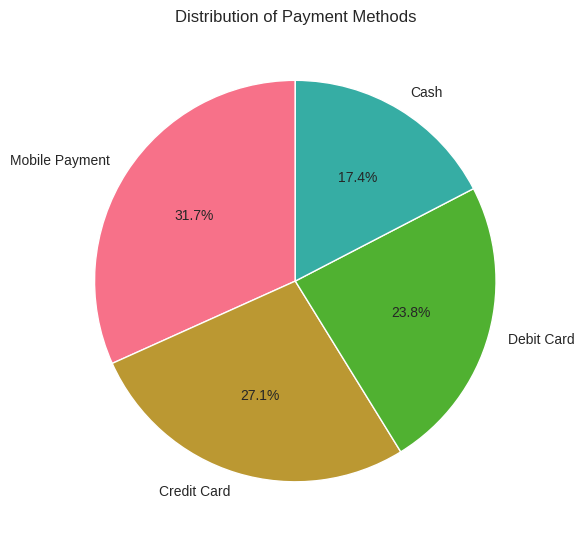

График сохранен: /tmp/pie_chart.png


In [15]:
# 1. Pie chart популярных способов оплаты (по количеству транзакций).
# Подготовка данных к визуализации

payment_dist_query = """
SELECT
    payment_method,
    COUNT(*) AS transaction_count,
    ROUND(
        COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (),
        2
    ) AS share_percent
FROM payments
GROUP BY payment_method
ORDER BY transaction_count DESC
"""

# Конвертация в Pandas для визуализации
payment_dist_df = spark.sql(payment_dist_query).toPandas()

# Визуализация 1: Pie chart популярных способов оплаты (по количеству транзакций)
payment_order = ["Mobile Payment", "Credit Card", "Debit Card", "Cash"]

payment_dist_df = (
    payment_dist_df
    .set_index("payment_method")
    .loc[payment_order]
    .reset_index()
)

plt.figure(figsize=(6, 6))

plt.pie(
    payment_dist_df["transaction_count"],
    labels=payment_dist_df["payment_method"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white"},
)

plt.title("Distribution of Payment Methods")

# сохранение графика
plt.tight_layout()
plt.savefig('/tmp/pie_chart.png', dpi=300, bbox_inches='tight')
plt.show()

print("График сохранен: /tmp/pie_chart.png")

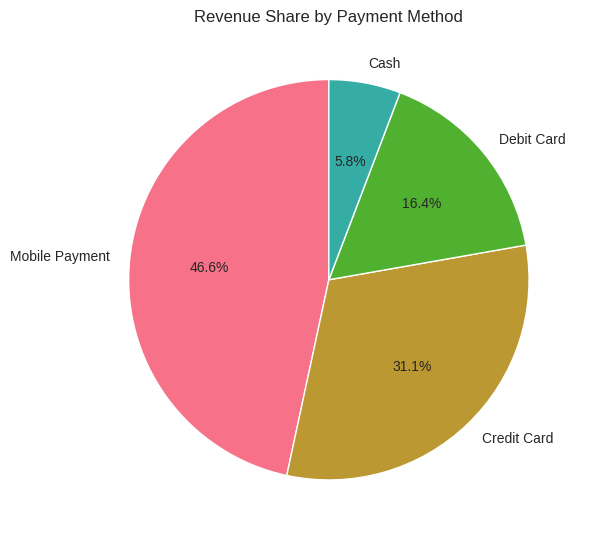

График сохранен: /tmp/Revenue_share.png


In [16]:
# 2. Доля выручки в зависимости от способа оплаты (Pie chart по обороту).

revenue_share_query = """
SELECT
    payment_method,
    SUM(quantity * unit_price * (1 - discount_applied)) AS total_revenue
FROM payments
GROUP BY payment_method
"""

revenue_share_df = spark.sql(revenue_share_query).toPandas()

plt.figure(figsize=(6, 6))
payment_order = ["Mobile Payment", "Credit Card", "Debit Card", "Cash"]
revenue_share_df = (
    revenue_share_df
    .set_index("payment_method")
    .loc[payment_order]
    .reset_index()
)

plt.pie(
    revenue_share_df["total_revenue"],
    labels=revenue_share_df["payment_method"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white"},
)

plt.title("Revenue Share by Payment Method")
plt.tight_layout()

plt.savefig('/tmp/Revenue_share.png', dpi=300, bbox_inches='tight')
plt.show()

print("График сохранен: /tmp/Revenue_share.png")

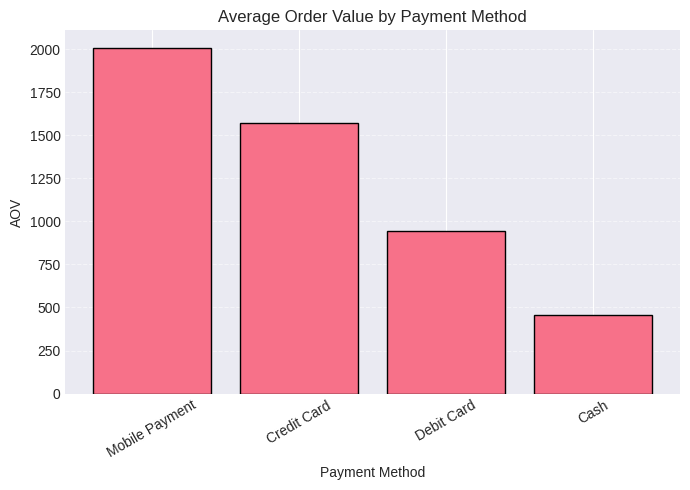

График сохранен: /tmp/aov.png


In [13]:
# 3. AOV (средний чек) по способам оплаты

aov_query = """
SELECT
    payment_method,
    ROUND(AVG(quantity * unit_price * (1 - discount_applied)), 2) AS avg_order_value
FROM payments
GROUP BY payment_method
ORDER BY avg_order_value DESC
"""
aov_df = spark.sql(aov_query).toPandas()

plt.figure(figsize=(7, 5))

bars = plt.bar(
    aov_df["payment_method"],
    aov_df["avg_order_value"],
    edgecolor="black"
)

plt.title("Average Order Value by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("AOV")

plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig('/tmp/aov.png', dpi=300, bbox_inches='tight')
plt.show()

print("График сохранен: /tmp/aov.png")

## 8. Итоговая аналитика и выводы

In [17]:
print("="*80)
print("ИТОГОВЫЙ ОТЧЕТ: Анализ методов оплаты и поведения клиентов")
print("="*80)

# 1. Общая статистика

total_transactions = df.count()

unique_payment_methods = df.select("payment_method").distinct().count()

total_revenue = df.selectExpr(
    "SUM(quantity * unit_price * (1 - discount_applied)) as revenue"
).collect()[0]["revenue"]

avg_order_value_total = df.selectExpr(
    "AVG(quantity * unit_price * (1 - discount_applied)) as aov"
).collect()[0]["aov"]

print(f" 1. Общая статистика:")
print(f"Всего транзакций: {total_transactions:,}")
print(f"Уникальных способов оплаты: {unique_payment_methods}")
print(f"Общая выручка: {total_revenue:,.2f}")
print(f"Средний чек: {avg_order_value_total:,.2f}")


# 2. Структура по способам оплаты

payment_stats_pd = payment_analysis.toPandas()

print(f"\n 2. Структура по способам оплаты:")

for _, row in payment_stats_pd.iterrows():
    print(f"{row['payment_method']: <15} | "
          f"Транзакций: {row['transaction_count']:>8,} | "
          f"Доля: {row['share_percent']:>6.2f}%")

# 3. Сравнение среднего чека (AOV)

aov_pd = aov_analysis.toPandas()

print(f"\n 3. Средний чек (AOV) по способам оплаты:")

for _, row in aov_pd.iterrows():
    print(f" {row['payment_method']: <15} | "
          f"AOV: {row['avg_order_value']:>10,.2f}")

# 4. Выручка по способам оплаты

revenue_pd = revenue_share_df.copy()

total_revenue_calc = revenue_pd["total_revenue"].sum()

print(f"\n 4. Доля выручки по способам оплаты:")

for _, row in revenue_pd.iterrows():
    share = row["total_revenue"] / total_revenue_calc * 100
    print(f"  • {row['payment_method']: <15} | "
          f"Выручка: {row['total_revenue']:>12,.2f} | "
          f"Доля: {share:>6.2f}%")

# 5. Бизнес-выводы

top_payment = payment_stats_pd.iloc[0]["payment_method"]
top_aov_method = aov_pd.sort_values("avg_order_value", ascending=False).iloc[0]["payment_method"]

print(f"\n 5. Ключевые выводы:")

print(f"1. Самый популярный способ оплаты: {top_payment}")
print(f"2. Самый высокий средний чек наблюдается при оплате: {top_aov_method}")
print(f"3. Mobile Payment является основным драйвером бизнеса, обеспечивая большую часть всей выручки и основную часть всех транзакций.")
print(f"4. Сегмент Credit Card демонстрирует высокий средний чек, однако уступает Mobile Payment как по количеству операций, так и по общей выручке.")
print(f"5. Наличные демонстрируют минимальную долю выручки и самый низкий средний чек.")
print(f"6. Наблюдается умеренная сегментация: мобильные платежи используются как для массовых, так и для относительно крупных покупок, в то время как наличные преимущественно применяются для мелких транзакций.")
print(f"7. Несмотря на схожую долю транзакций между Credit Card и Debit Card, вклад в выручку существенно различается за счет различий в среднем чеке.")

# 6. Рекомендации

print(f"\n 6. Рекомендации:")

print(f"1. Сфокусировать развитие мобильных платежей как ключевого канала генерации выручки, усиливая пользовательский опыт и программы лояльности внутри мобильного приложения.")
print(f"2. Сохранить и поддерживать сегмент Credit Card как канал покупок с высоким средним чеком, внедряя премиальные предложения и специальные акции для крупных заказов.")
print(f"3. Оптимизировать издержки, связанные с обслуживанием наличных расчетов, учитывая их низкий вклад в выручку и минимальный средний чек, например, заменив традиционные кассы аппаратами самообслуживания и автоматизированными терминалами.")
print(f"4. Разработать инструменты повышения среднего чека в сегменте Debit Card (персонализированные предложения, кросс-продажи и так далее), поскольку при сопоставимой доле транзакций данный сегмент генерирует меньшую выручку из-за более низкого AOV.")

print("\n" + "="*80)
print("Анализ методов оплаты завершен успешно")
print("="*80)

ИТОГОВЫЙ ОТЧЕТ: Анализ методов оплаты и поведения клиентов


 1. Общая статистика:
Всего транзакций: 545,266
Уникальных способов оплаты: 4
Общая выручка: 745,791,673.51
Средний чек: 1,367.76

 2. Структура по способам оплаты:
Mobile Payment  | Транзакций:  173,000 | Доля:  31.73%
Credit Card     | Транзакций:  147,647 | Доля:  27.08%
Debit Card      | Транзакций:  129,827 | Доля:  23.81%
Cash            | Транзакций:   94,792 | Доля:  17.38%

 3. Средний чек (AOV) по способам оплаты:
 Credit Card     | AOV:   1,573.14
 Debit Card      | AOV:     944.45
 Cash            | AOV:     455.32

 4. Доля выручки по способам оплаты:
  • Mobile Payment  | Выручка: 347,746,423.54 | Доля:  46.63%
  • Credit Card     | Выручка: 232,268,758.75 | Доля:  31.14%
  • Debit Card      | Выручка: 122,615,704.81 | Доля:  16.44%
  • Cash            | Выручка: 43,160,786.42 | Доля:   5.79%

 5. Ключевые выводы:
1. Самый популярный способ оплаты: Mobile Payment
2. Самый высокий средний чек наблюдается при оплате: Credit Card
3. Mobile Payment является основным драйвером

# 9. Сохранение результатов в output

Команды в терминале:

hdfs dfs -mkdir -p /user/hadoop/pw01_var25/output

hdfs dfs -chmod -R 777 /user/hadoop/pw01_var25



In [18]:
# Сохранение результатов в HDFS

output_path_structure = "hdfs://localhost:9000/user/hadoop/pw01_var25/output/payment_structure"
output_path_aov = "hdfs://localhost:9000/user/hadoop/pw01_var25/output/aov_analysis"
output_path_revenue = "hdfs://localhost:9000/user/hadoop/pw01_var25/output/revenue_analysis"

# 1. Структура оплат
payment_analysis.write.mode('overwrite') \
    .option("header", "true") \
    .csv(output_path_structure)

# 2. AOV
aov_analysis.write.mode('overwrite') \
    .option("header", "true") \
    .csv(output_path_aov)

# 3. Выручка
revenue_df_spark = spark.sql("""
SELECT
    payment_method,
    SUM(quantity * unit_price * (1 - discount_applied)) AS total_revenue
FROM payments
GROUP BY payment_method
""")

revenue_df_spark.write.mode('overwrite') \
    .option("header", "true") \
    .csv(output_path_revenue)

print("Результаты сохранены в HDFS:")
print(f"{output_path_structure}")
print(f"{output_path_aov}")
print(f"{output_path_revenue}")


# Сохранение результатов локально (не в HDFS)
payment_analysis.toPandas().to_csv('/tmp/payment_structure.csv', index=False)
aov_analysis.toPandas().to_csv('/tmp/aov_analysis.csv', index=False)
revenue_df_spark.toPandas().to_csv('/tmp/revenue_analysis.csv', index=False)

print("Результаты сохранены локально:")
print("/tmp/payment_structure.csv")
print("/tmp/aov_analysis.csv")
print("/tmp/revenue_analysis.csv")

Результаты сохранены в HDFS:
hdfs://localhost:9000/user/hadoop/pw01_var25/output/payment_structure
hdfs://localhost:9000/user/hadoop/pw01_var25/output/aov_analysis
hdfs://localhost:9000/user/hadoop/pw01_var25/output/revenue_analysis


Результаты сохранены локально:
/tmp/payment_structure.csv
/tmp/aov_analysis.csv
/tmp/revenue_analysis.csv


#Проверка локальных файлов

!ls -lh /tmp/payment_structure.csv /tmp/aov_analysis.csv /tmp/revenue_analysis.csv

!head -5 /tmp/payment_structure.csv

In [88]:
# Остановка SparkSession
spark.stop()
print("SparkSession остановлен")

SparkSession остановлен
